<a href="https://colab.research.google.com/github/omorsi45/machine-learning-comp432-labs/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab-Week6 Recurrent Neural Networks


In this lab, you will familiarize yourself with **recurrent neural networks** (RNNs) (which was the topic of the main lecture). Specifically, you'll solve three toy tasks of different typologies:

1. **Does it contain ones?** *(L-to-1 problem)*, where an RNN has to encode a binary input sequence and predict (at the end) if the sequence contains at least a "1".

2. **Binary Adder** *(L-to-L problem)*, where an RNN takes in input two binary numbers and has to return their sum.

3. **Copy Task** *(seq-to-seq problem)*, where an RNN encodes a binary sequence, and another RNN (decoder) has to replay the original input using the last encoded state only.

4. **Sinusoid prediction** *(autoregressive L-to-L problem)*, where we employ an autoregressive RNN to predict the next value that a sinusoid will take.

Moreover, there is the following **optional** exercise:

5. **Language Modeling** *(autoregressive L-to-L problem)*, where we employ an autoregressive RNN to predict the next character of a text. We will also use this RNN to generate Shakespeare-like plays. This exercise is optional and it is not graded. However, we will encourage all the students to solve it as it is very formative.

We will implement these systems with [PyTorch](https://pytorch.org/tutorials/).

As you might have guessed, we do not really need neural networks to solve the simple tasks above. However, solving these toy tasks will help you to figure out how to deploy machine learning systems that involve RNNs. You can use the same core code on real sequence processing problems (you just have to train the model with more data and enough computing).

<span style="color:red"><i>Warning.</i></span> Many of the code cells in this notebook re-use the variable names like `X` or `y`, but assign them different data. If you run cells out of order, you may get unexpected results or errors, so be careful when switching between exercises.

**Run the code cell below** to import the PyTorch and to set the seed (for replicability).

In [1]:
import matplotlib.pyplot as plt
import math
import torch
torch.manual_seed(0)

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

## 1. Does it contain ones?

In this case, we have in input a sequence of $L$ binary elements (randomly sampled). If there is at least a "1" in that sequence, the output produced by the neural network should be "1". Otherwise, it must be 0.

For instance:
- If $\mathbf{x}=[0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0]$, the output should be 1
- If $\mathbf{x}=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]$, the output should be 0
- If $\mathbf{x}=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]$, the output should be 1

It is possible to solve this problem with an RNN (see Figure below).

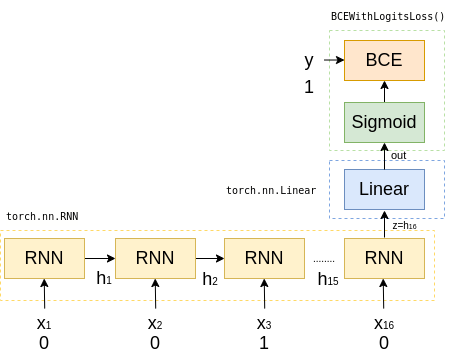

The RNN scans all the elements of the current input sequence $\mathbf{x}=[x_1,x_2,..,x_L]^T$. It outputs a sequence of states $\mathbf{H}$ (one for each time step). For instance, if we use a vanilla RNN:

$\mathbf{h}_t = tanh(\mathbf{W}^{(in)T} \mathbf{x}_t + \mathbf{W}^{(hh)T} \mathbf{h}_{t-1})$

$\mathbf{H}=[\mathbf{h}_1, \mathbf{h}_2, ...,\mathbf{h}_{t-1},\mathbf{h}_t,...,\mathbf{h}_L]^T = \begin{bmatrix}
h_{1,1} & h_{1,2} & ... & h_{1,M}\\
h_{2,1} & h_{2,2} & ... & h_{2,M}\\
... & ... & ... & ...\\
h_{L,1} & h_{L,2} & ... & h_{L,M}\\
\end{bmatrix}$,

where $\mathbf{W}^{(in)}$ and $\mathbf{W}^{(hh)}$ are the learnable parameters. $L$ is the number of elements in the sequence and $M$ is the dimensionality of the hidden state (*hidden_size*).  

Now, we can take the final state $\mathbf{h}_L$ and feed it into a **binary classifier** (based on a linear transformation followed by a sigmoid). The classifier should output something close to zero if the input sequence $\mathbf{x}$ does not contain ones, and something close to one otherwise.  

On top of the classifier, we plug the BCE loss that compares the predictions with the labels (at training time).

We can train this model as already done many times in this course: we have to compute a gradient using the **backpropagation** algorithm and update the parameters with **gradient descent**. Fortunately, we will use PyTorch, which will compute gradients for us using its automatic differentiation engine.

At this level, the problem to solve should be clear enough to you. Let's start by generating some data for training our model:



### Exercise 1.1 &mdash; Create a synthetic dataset

The Python function below generates $N$ binary sequences of length $L$. The sequences are sampled randomly using the Bernoulli distribution implemented in `torch.bernoulli`. The argument `prob` is the probability to draw a one, which is set to "0.05".  This way, we approximately have 50% of the sequences with ones and 50% that only contain zeros.


**Run the code cell below** to get the generate_data function.

In [2]:
def generate_data(N, L, D=1, prob=0.05):
  """This function generates random sequences of 0 and 1.
  The label is 1 if there is at least one element of the
  sequence that contains 1.

  Arguments
  ---------
  N: int
    Number of examples.
  L : int
    Lenght of the sequences.
  D: int
    Number of output features.
  prob: float:
    Probability to draw a 1.

  Returns
  ---------
  X: torch.Tensor
    Tensor of dimensionality (L,N,D) containing
    the generated sequences.
  y: torch.Tensor
    Tensor of dimensionality (N,1) containing the labels.
  """
  X = torch.bernoulli(torch.full((N, L, D), prob)).float()
  y = torch.any (X >= 1.0, dim=1).float()
  return X, y

**Write a code** to call the `generate_data` and create the training dataset. Please, store the input sequences in a variable called "inputs", and the output labels in a variable called $labels$.

In [3]:
num_ex = 1000 # number of examples
seq_len = 16 # sequence length
n_out_feats = 1 # output features

# Generate data
inputs, labels = generate_data(num_ex, seq_len, n_out_feats)

print(inputs.shape)
print(labels.shape)

torch.Size([1000, 16, 1])
torch.Size([1000, 1])


**Check your answer** by running the code cell below.

In [4]:
assert isinstance(inputs, torch.Tensor), "Expected inputs to be a torch.Tensor"
assert isinstance(labels, torch.Tensor), "Expected labels to be a torch.Tensor"
assert inputs.shape == (1000, 16, 1), "inputs has a wrong shape"
assert labels.shape == (1000, 1), "labels has a wrong shape"
y_lab = (inputs.sum(1)>0).float()
assert (labels-y_lab).sum()==0, "Labels y not corrected"
print("Correct!")

Correct!


### Exercise 1.2 &mdash; Create the Model

We are now ready to implement the model described above. When working with a `torch.nn.Module` class (see code below), we normally have to fill two methods: the $\_\_init\_\_$ one (which is called only once when initializing the class) and the $foward$ one that specifies all the computations from the input to the output prediction.

In particular:
- The $\_\_init\_\_$ method has to initialize an RNN with [torch.nn.RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html). Please,  use `batch_first=True`. It also has to initialize a linear transformation with [torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html). The linear transformation has to transform the last hidden state of the RNN into a single scalar (i.e., use `out_features=1`).

- The $forward$ method has to first feed the inputs into the RNNs. Then, it has to run the linear transformation on top of the last hidden layer. When the model is in the "training" modality (`self.training`), the output before the sigmoid is returned (the reason is that we are going to use the `torch.nn.BCEWithLogitsLoss` as loss, which assumes logits in input). When the model is in eval modality, we have to apply the sigmoid (`torch.sigmoid`) on top of the linear transformation.


**Complete the code** to implement the desired model:

In [5]:
class VanillaRNN(torch.nn.Module):
  def __init__(self, input_size=1, hidden_size=1, num_layers=2):
    super(VanillaRNN, self).__init__()
    self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
    self.linear = torch.nn.Linear(hidden_size, 1)
    torch.nn.init.xavier_uniform_(self.linear.weight)

  def forward(self, x):
    Z, h_n = self.rnn(x)
    self.Z = Z
    z = Z[:, -1, :]
    out = self.linear(z)

    if not self.training:
      out = (torch.sigmoid(out) > 0.5).float()

    return out

**Check your answer** by running the code cell below.

In [6]:
linear_layer = None
rnn_layer = None

# Search for the layers dynamically
rnn = VanillaRNN(input_size=1, hidden_size=4, num_layers=2)
for module in rnn.modules():
    if isinstance(module, torch.nn.Linear):
        linear_layer = module
    if isinstance(module, torch.nn.RNN):
        rnn_layer = module

assert linear_layer is not None, "Linear layer is missing."
assert rnn_layer is not None, "RNN layer is missing."
rnn.train()
out = rnn(inputs[0:100,:,:])
assert out.shape==(100,1), "The output of the RNN has an unexpected shape"
rnn.eval()
out = rnn(inputs[0:100,:,:])
assert out.shape==(100,1), "The output of the RNN has an unexpected shape (in eval mode)"
cnt_0 = torch.count_nonzero(out)
cnt_1 = torch.count_nonzero(1 - out.int())
assert cnt_0 + cnt_1 == 100, "The prediction returned in eval model must be only be 0. \
                              Make sure the threshold is applied"
print("Correct!")

Correct!


### Exercise 1.3 &mdash; Training loop

Let's now write the training loop (this step is similar to what was done in previous labs).

**Complete the code** to implement the training loop:

In [21]:
# Hyperparameters
learning_rate = 0.01
batch_size = 100
num_epoch = 500
hidden_dim = 1
layer_count = 2

# Initialize the Vanilla RNN
# Aim for 1 line
rnn = VanillaRNN(input_size=1, hidden_size=hidden_dim, num_layers=layer_count)

# Initialize the Loss. Please, use torch.nn.BCEWithLogitsLoss
# Aim for 1 line
criterion = torch.nn.BCEWithLogitsLoss()

# Initialize the Optimizer. Please, use torch.optim.Adam
# Aim for 1 line
optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(num_epoch):
    for i in range(0, num_ex, batch_size):

        # Read minibatches (for both X and y)
        # Aim for 2 lines
        x_batch = inputs[i : i + batch_size]
        y_batch = labels[i : i + batch_size]

        # Run the model
        # Aim for 1 line
        outputs = rnn(x_batch)

        # Compute the loss (use l as variable for the loss)
        # Aim for 1 line
        l = criterion(outputs, y_batch)

        # Update the parameters
        # Aim for 3 lines
        optimizer.zero_grad()
        l.backward()
        optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print("Epoch %03d: Train_loss: %.4f " % (epoch + 1, l.item()))

Epoch 050: Train_loss: 0.0183 
Epoch 100: Train_loss: 0.0063 
Epoch 150: Train_loss: 0.0032 
Epoch 200: Train_loss: 0.0019 
Epoch 250: Train_loss: 0.0012 
Epoch 300: Train_loss: 0.0008 
Epoch 350: Train_loss: 0.0006 
Epoch 400: Train_loss: 0.0004 
Epoch 450: Train_loss: 0.0003 
Epoch 500: Train_loss: 0.0002 


**Check your answer** by running the code cell below.

In [22]:
rnn.eval()
X_test = torch.zeros(10,16,1)
assert (rnn(X_test)).sum()==0, "Incorrect prediction. Problems during training?"
assert (rnn(X_test+1)).sum()==10, "Incorrect prediction. Problems during training?"
rnn.train()
print("Correct!")

Correct!


Your output should look like this:

```
Epoch 050: Train_loss: 0.0185
Epoch 100: Train_loss: 0.0063
Epoch 150: Train_loss: 0.0032
Epoch 200: Train_loss: 0.0019
Epoch 250: Train_loss: 0.0012
Epoch 300: Train_loss: 0.0008
Epoch 350: Train_loss: 0.0006
Epoch 400: Train_loss: 0.0004
Epoch 450: Train_loss: 0.0003
Epoch 500: Train_loss: 0.0002
```

As you can see,  even a tiny neural network like the one used here can easily solve this problem.

Let's now see if it works on some test data as well:

**Complete the code** to test the model on the provided inputs:

In [28]:
# Create Test samples
input_test = torch.zeros(3,16,1)
input_test[0,8,0] = 1
input_test[1,2,0] = 1
input_test[1,12,0] = 1

# Switch model to eval mode
model.eval()

# Run prediction - storing output in 'pred' so the assertion cell below works
pred = model(input_test)

# Print prediction
print(pred)

tensor([[1.],
        [1.],
        [0.]])


**Check your answer** by running the code cell below.

In [29]:
assert pred[0,0]==True, "Incorrect prediction. Problems during training?"
assert pred[1,0]==True, "Incorrect prediction. Problems during training?"
assert pred[2,0]==False, "Incorrect prediction. Problems during training?"
print("Correct!")

Correct!


### Exercise 1.4 &mdash; Plot activations

You can now plot the hidden activations over the time axis (we can access them with `rnn.Z`). This can give us some insights into what the network has learned.

**Complete the code** to test the model on the provided inputs:

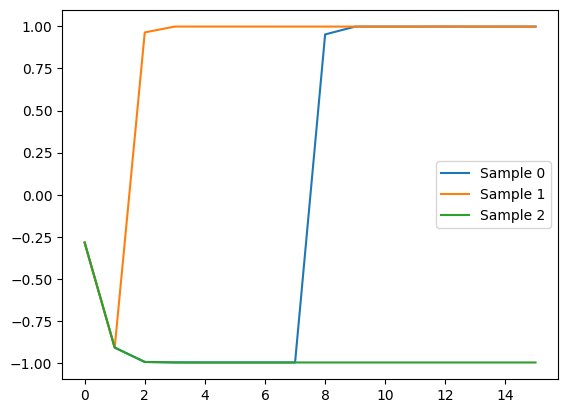

In [30]:
import matplotlib.pyplot as plt

for i in range(input_test.shape[0]):
    # Pass input through model to populate rnn.Z
    rnn(input_test[i:i+1])
    # Detach and plot the hidden state (Z) across the time axis (dim 1)
    plt.plot(rnn.Z.detach().squeeze(), label=f'Sample {i}')

plt.legend()
plt.show()

You should obtain images similar to this ones:

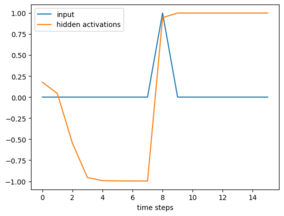

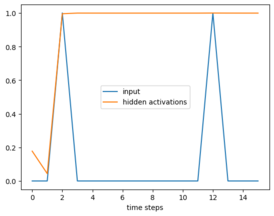

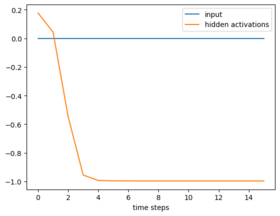

As you can see, the output tends to stay at -1 until a "1" is detected in the sequence. When a 1 is observed, the activation stays at around + 1 until the end. Note that also the opposite behavior might be learned by the network (the following linear transformation can just invert it).



# 2. Binary Adder

In this case, the RNN takes in input two binary numbers. The output is the sum of the binary inputs (take a look [here](http://web.math.princeton.edu/math_alive/1/Lab1/BinAdd.html), if you do not remember of binary addition works).

For instance:

with  $\mathbf{X} = \begin{bmatrix}
0 & 1 \\
0 & 1 \\
0 & 0 \\
1 & 1 \\
0 & 1 \\
0 & 0 \\
1 & 1 \\
0 & 0 \\
\end{bmatrix}$,
the output must be $\mathbf{y} = \begin{bmatrix}
1 \\
1 \\
1 \\
0 \\
1 \\
1 \\
0 \\
0 \\
\end{bmatrix}$.

By default, the first row represents the most significant bit, while the last one represents the least significant bit (i.e., the summation starts from the last element and goes step by step to the first one).  


It is possible to solve this problem with an RNN (see Figure below).

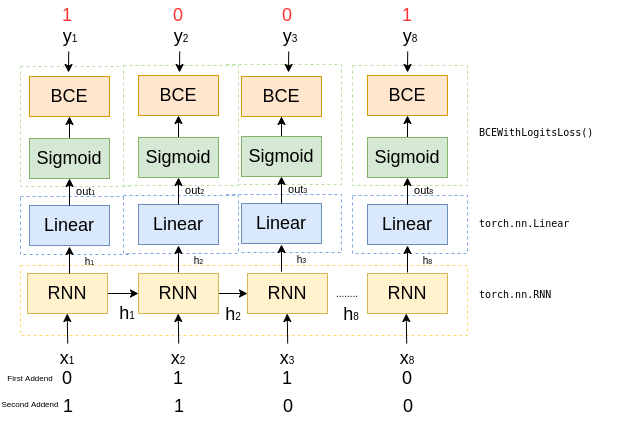

In this case, we need a prediction for each time step.  An RNN scans the inputs from the least important bit to the most important one. We here assume that each binary number is composed of L=8 bits.  The RNN produces a sequence of L hidden states. On top of each hidden state, we apply a binary classifier (linear transformation + sigmoid) that will predict the current output value.

During training, we use the binary cross-entropy loss to compare the predictions with the labels.

First of all, let's create a synthetic dataset for this task.

### Exercise 2.1 &mdash; Create a synthetic dataset

The following functions will be useful to create a synthetic dataset. The function  `dec2bin` converts the integers contained in the tensor into their corresponding binary values.  The function `bin2dec` performs the opposite conversion.


**Run the code cell below** to get these functions.

In [31]:
def decimal_to_binary(x, bits):
    """Converts the decimal numbers in the input tensor to binary numbers with the
    specified number of bits."""
    mask = 2 ** torch.arange(bits - 1, -1, -1).to(x.device, x.dtype)
    return x.unsqueeze(-1).bitwise_and(mask).ne(0).float()

def binary_to_decimal(b, bits):
    """Converts the binary numbers in the input tensor to decimal numbers."""
    mask = 2 ** torch.arange(bits - 1, -1, -1).to(b.device, b.dtype)
    return torch.sum(mask * b, -1)

**Complete the code** to convert the given input tensor into a binary one using `dec2bin`. Use $L=8$ as bit resolution.

In [33]:
x_decimal = torch.tensor([[2, 5],[8,18]])
seq_len = 8

# Convert the given input tensor into a binary one
binary_x = decimal_to_binary(x_decimal, bits=seq_len)

# Print the results
print(binary_x)
print(binary_x.shape)

tensor([[[0., 0., 0., 0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 0., 1., 0., 1.]],

        [[0., 0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 1., 0.]]])
torch.Size([2, 2, 8])


**Check your answer** by running the code cell below.

In [34]:
assert (binary_x[0,0,:]-torch.Tensor([0., 0., 0., 0., 0., 0., 1., 0.])).sum()==0, "Incorrect conversion"
assert (binary_x[0,1,:]-torch.Tensor([0., 0., 0., 0., 0., 1., 0., 1.])).sum()==0, "Incorrect conversion"
assert (binary_x[1,0,:]-torch.Tensor([0., 0., 0., 0., 1., 0., 0., 0.])).sum()==0, "Incorrect conversion"
assert (binary_x[1,1,:]-torch.Tensor([0., 0., 0., 1., 0., 0., 1., 0.])).sum()==0, "Incorrect conversion"
print("Correct!")

Correct!


**Complete the code** to convert the given binary tensor into an integer one using `bin2dec`. Use $L=8$ as bit resolution.

In [35]:
x_binary = torch.tensor([[0,0,0,0,0,0,1,0],[0,0,0,0,0,1,1,1], [1,1,1,1,1,1,1,1]])
# Convert the binary tensor into an integer one
x_decimal = binary_to_decimal(x_binary, bits=seq_len)

# Print the results
print(x_decimal)
print(x_decimal.shape)

tensor([  2,   7, 255])
torch.Size([3])


**Check your answer** by running the code cell below.

In [36]:
assert (x_decimal-torch.Tensor([2,7,255])).sum()==0, "Incorrect conversion"
print("Correct!")

Correct!


We can now create a synthetic dataset for training our model.

**Run the code cell below** to get the data generation function.

In [37]:
def generate_binary_sum_data(N, bits=8):
  """This function generates data, where each sample is composed of two random
  binary numbers to add. Each label is a binary number corresponding to the sum
  of the two inputs.

  Arguments
  ---------
  N: int
    Number of examples.
  bits : int
    The bit resolution of the binary numbers.


  Returns
  ---------
  X: torch.Tensor
    Tensor of dimensionality (N,bits,2) containing the binary numbers to add.
  y: torch.Tensor
    Tensor of dimensionality (N, bits) containing the labels (i.e, the sum of two binary numbers).
  """

  # Matrix containing integers between 0 and 127
  X = torch.randint(low=0, high=128, size=(N,2))

  # Label (in decimal format)
  y = X.sum(dim=1)

  # Conversion to binary
  Xb =  decimal_to_binary(X,8).transpose(1,2)
  yb = decimal_to_binary(y,8)

  return Xb, yb



**Complete the code** to call the `binary_sum_generation` function and generate the training data.

In [38]:
# Data generation
num_ex = 1000

# Call the function and store the result in inputs and labels
inputs, labels = generate_binary_sum_data(num_ex, bits=8)

print(inputs.shape)
print(labels.shape)

torch.Size([1000, 8, 2])
torch.Size([1000, 8])


**Check your answer** by running the code cell below.

In [39]:
a = binary_to_decimal(inputs[:,:,0],8)
b = binary_to_decimal(inputs[:,:,1],8)
c = binary_to_decimal(labels[:,:],8)
assert ((a + b == c).int().sum()==num_ex), "Wrong Labels"
print("Correct!")

Correct!


### Exercise 2.2 &mdash; Create the Model

We are now ready to implement the model described above.

In particular:
- Similarly to Exercise 1.2, the $\_\_init\_\_$ has to initialize an RNN and a linear transformation. Please use `batch_first=True` for the RNN.


- The $forward$ method has to feed the inputs into the RNN. Then, it has to run the linear transformation on top of each hidden layer (this is the main difference from  Exercise 1.2). When the model is in the "training" modality (`self.training`), the output before the sigmoid is returned (the reason is that we are going to use the `torch.nn.BCEWithLogitsLoss` as loss, which assumes logits in input). When the model is in eval modality, we have to apply the sigmoid (`torch.sigmoid`) on top of the linear transformation.


Note that the RNN should scan the sequence starting from the least important bit.
This means that you have to flip the input tensor along the time axis (use `torch.flip`), do the computations, and flip everything again before returning the output. You can do this within the  $forward$ method.


**Complete the code** to implement the desired model:

In [40]:
class VanillaRNN(torch.nn.Module):
  def __init__(self, input_size=2, hidden_size=16, num_layers=1):
    super(VanillaRNN, self).__init__()
    # Initialize the RNN
    self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

    # Initialize the Linear transformation
    self.linear = torch.nn.Linear(hidden_size, 1)

    # Initialize the Linear layer's parameters using Xavier uniform
    torch.nn.init.xavier_uniform_(self.linear.weight)

  def forward(self, X):
    # Flip X (over the time axis to process from least significant to most significant bit)
    X = torch.flip(X, dims=[1])

    # Run RNN
    Z, h_n = self.rnn(X)

    # Apply linear transform (on top of each hidden state)
    out = self.linear(Z)

    # Flip again to retrieve the standard bit order
    out = torch.flip(out, dims=[1])

    # Managing eval mode
    if not self.training:
      # Apply a threshold on the top of the sigmoid.
      out = (torch.sigmoid(out) > 0.5).float()

    return out

**Check your answer** by running the code cell below.

In [41]:
rnn = VanillaRNN(input_size=2, hidden_size=4, num_layers=2)
rnn.train()
out = rnn(inputs[0:100,:,:])
assert out.shape==(100,8,1), "The output of the RNN has an unexpected shape"
rnn.eval()
out = rnn(inputs[0:100,:,:])
assert out.shape==(100,8,1), "The output of the RNN has an unexpected shape (in eval mode)"
cnt_0 = torch.count_nonzero(out)
cnt_1 = torch.count_nonzero(1 - out.int())
assert cnt_0 + cnt_1 == 100 * 8, "The prediction returned in eval model must be only be 0. \
                              Make sure the threshold is applied"
print("Correct!")

Correct!


# 2.3 Training Loop
Write the training loop for training this model. The training loop is very similar to that written for Exercise 1.2.

**Complete the code** to implement the training loop:

In [43]:
# Hyperparameters
num_epoch = 500
batch_size = 100
lr = 0.002
hidden_size = 8
num_layers = 1

# Initialize the VanillaRNN model
rnn = VanillaRNN(input_size=2, hidden_size=hidden_size, num_layers=num_layers)

# Initialize the optimizer. Use torch.optim.Adam with the specified lr.
optimizer = torch.optim.Adam(rnn.parameters(), lr=lr)

# Initialize the loss. Use torch.nn.BCEWithLogitsLoss.
loss_fn = torch.nn.BCEWithLogitsLoss()

# Training Loop
for epoch in range(num_epoch):
    for i in range(0, num_ex, batch_size):

        # Minibatch selection (for X and Y)
        Xi = inputs[i : i + batch_size]
        yi = labels[i : i + batch_size]

        # Running the RNN
        # Forward pass returning (N, L, 1)
        logits = rnn(Xi)
        # Squeeze to match label shape (N, L)
        logits = logits.squeeze(-1)

        # Apply the loss
        l = loss_fn(logits, yi)

        # Update parameters
        optimizer.zero_grad()
        l.backward()
        optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print("Epoch %03d: Train_loss: %.4f " % (epoch + 1, l.item()))

Epoch 050: Train_loss: 0.6647 
Epoch 100: Train_loss: 0.1789 
Epoch 150: Train_loss: 0.0389 
Epoch 200: Train_loss: 0.0173 
Epoch 250: Train_loss: 0.0101 
Epoch 300: Train_loss: 0.0066 
Epoch 350: Train_loss: 0.0044 
Epoch 400: Train_loss: 0.0030 
Epoch 450: Train_loss: 0.0019 
Epoch 500: Train_loss: 0.0011 


You should see something like this in output:


```
Epoch 050: Train_loss: 0.3216
Epoch 100: Train_loss: 0.0400
Epoch 150: Train_loss: 0.0153
Epoch 200: Train_loss: 0.0079
Epoch 250: Train_loss: 0.0046
Epoch 300: Train_loss: 0.0029
Epoch 350: Train_loss: 0.0019
Epoch 400: Train_loss: 0.0013
Epoch 450: Train_loss: 0.0008
Epoch 500: Train_loss: 0.0006
```



As you can see, the model converges fast also in this case.
We can feed some test data to double-check that everything is fine.

**Complete the code** to implement to evaluate the model on the provided inputs.


In [45]:
# Decimal numbers
a = torch.tensor([101, 3, 23])
b = torch.tensor([67, 91, 12])
c = a + b

# Conversion to binary numbers (8-bit resolution)
# Ensure we add the extra dimension for the concatenation
a_bin = decimal_to_binary(a, 8).unsqueeze(2)
b_bin = decimal_to_binary(b, 8).unsqueeze(2)

# Concatenate a and b in a single tensor to get shape (3, 8, 2)
X_test = torch.cat([a_bin, b_bin], dim=2)

# Put the model in eval mode to enable thresholding
rnn.eval()

# Run the model
out = rnn(X_test)

# Convert the output to decimal format
# out[:,:,0] extracts the (N, L) binary predictions from the (N, L, 1) output
out_decimal = binary_to_decimal(out[:, :, 0], 8)

print("Model Predictions:", out_decimal)
print("Actual Sums:", c)

Model Predictions: tensor([168.,  94.,  35.])
Actual Sums: tensor([168,  94,  35])


**Check your answer** by running the code cell below.

In [46]:
assert  sum(out_decimal - torch.tensor([168,  94,  35]))==0, "Wrong prediction"
print('correct')

correct


# 3. Copy Task
We now try to solve another toy task. This time, we want to use RNNs to solve a variant of the famous copy task. Basically, we read the inputs with an RNN (called encoder). We then ask another RNN (called decoder) to replay the original inputs (in the same order) given the last encoded state only.

The figure below shows how we can use RNNs to approach this problem.


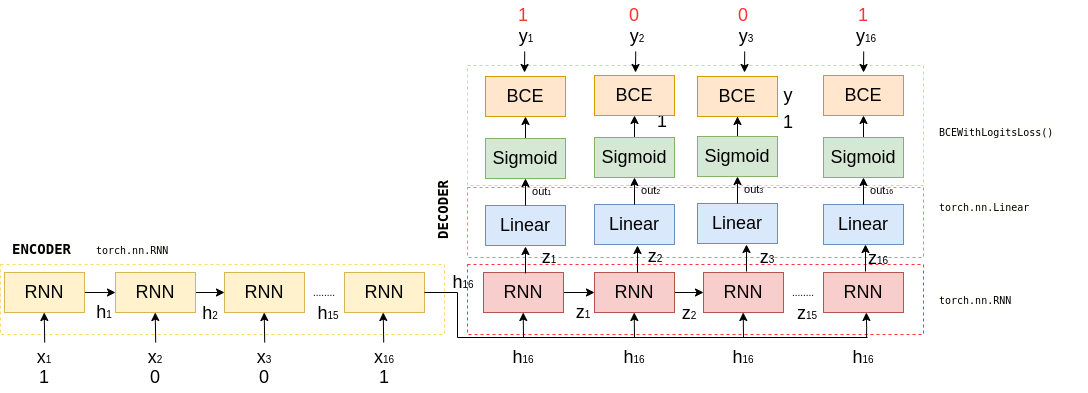

This time the problem can be framed as a **sequence-to-sequence** problem.

The encoder receives in input a sequence of L elements (for instance, $\mathbf{x} = [0,0,1,1,0,0,0,1,1,1]$). The encoder processes this sequences and outputs the hidden states $\mathbf{H}=[\mathbf{h}_1, \mathbf{h}_2, ..., \mathbf{h}_L]^T$.

The decoder takes in input $\mathbf{h}_L$ and has to regenerate $\mathbf{x} = [0,0,1,1,0,0,0,1,1,1]$ in output. We can feed $\mathbf{h}_L$ into all the inputs of the decoder. On top of each decoded hidden state, we can apply a binary classifier as done in Exercise 2.

Note that this task requires learning long-term dependencies because the input to replay is "far away" from the place where it is reconstructed.

Let's first create a dataset for this problem.

### Exercise 3.1 &mdash; Dataset Creation
We can create the dataset using the `generate_data` function implemented for Exercise 1. We have to set `prob=0.5` to approximatively have the same number of zeros and ones in the sequence.


**Run the following code** to generate the training dataset:

In [73]:
num_ex = 2000 # number of examples
seq_len = 16 # sequence length
n_out_feats = 1 # output features

inputs, _ = generate_data(num_ex, seq_len, n_out_feats, prob=0.5)

print(inputs.shape)

torch.Size([2000, 16, 1])


### Exercise 3.2 &mdash; Create the Model

We are now ready to implement the model described above.

In particular:
- The $\_\_init\_\_$ has to initialize two RNNs (one for the encoder and one for the decoder). Please use `batch_first=True` for both. We also have to initialize the linear transformation applied on top of all the decoded steps.


- The $forward$ method has to first feed the inputs into the RNN encoder. Then, we select the last hidden state and feed it into the RNN decoder (to all its inputs). On top of each hidden state of the decoder, we apply a linear transformation. When the model is in train modality (`self.training`), the output before the sigmoid is returned. When the model is in eval modality, we have to apply the sigmoid (`torch.sigmoid`) on top of the linear transformation.


**Complete the code** to implement the desired model:

In [74]:
class EncoderDecoderRNN(torch.nn.Module):
    def __init__(self, rnn_type=torch.nn.RNN, input_size=1, hidden_size=8, num_layers=1):
        super(EncoderDecoderRNN, self).__init__()
        # We here use rnn_type because we will also try an LSTM model.

        # Encoder initialization
        self.encoder = rnn_type(input_size, hidden_size, num_layers, batch_first=True)

        # Decoder initialization
        self.decoder = rnn_type(hidden_size, hidden_size, num_layers, batch_first=True)

        # Linear initialization
        self.linear = torch.nn.Linear(hidden_size, 1)

        # Initialize the Linear layer's parameters using Xavier uniform
        torch.nn.init.xavier_uniform_(self.linear.weight)

    def forward(self, X):
        """This function encodes the input sequences with an RNN. A decoder is fed with
        the last encoded state and generates an output sequence with the same length
        of the input one.

        Arguments
        ---------
        X : torch.Tensor
            Tensor containing the sequences (N, L, 1).

        Returns
        -------
        out: torch.Tensor
            Tensor (N,L,1) containing the logits for each decoded output.
        """
        # Run the RNN encoder
        H, _ = self.encoder(X)

        # Select the last hidden state
        h = H[:, -1:, :]

        # Feed all the decoding steps with the last hidden state.
        # This requires to concatenate h, L times over the time axis (dim=1)
        h_conc = h.repeat(1, X.size(1), 1)

        # Run the decoder (with the last state in inputs to all steps)
        Z, _ = self.decoder(h_conc)

        # Run the linear transformation
        out = self.linear(Z)

        if not(self.training):
            # Apply the sigmoid and a threshold on it.
            out = (torch.sigmoid(out) > 0.5).float()

        return out

### Exercise 3.3 &mdash; Training Loop
Now, we can train the model. This time, we implement the training loop in a function called `training_loop`. This way,  we can easily reuse it in the following:


**Complete the code** to implement the training loop:

In [75]:
# Hyperparameters
num_epoch = 1000
batch_size = 100
learning_rate = 0.004
hidden_dim = 16
layer_count = 1

# Initialization
rnn = EncoderDecoderRNN(input_size=1, hidden_size=hidden_dim, num_layers=layer_count)
loss = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate)

def training_loop(X, y, model, loss, optimizer, num_epoch=500, batch_size=100):

    # Getting number of input samples
    N = inputs.shape[0]

    # Training Loop
    for epoch in range(num_epoch):
        for i in range(0, N, batch_size):

            # Minibatch selection (on X and y)
            Xi = X[i:i+batch_size]
            yi = y[i:i+batch_size]

            # Run the RNN encoder/decoder
            logits = model(Xi)

            # Compute the loss
            l = loss(logits, yi)

            # Update the parameters
            optimizer.zero_grad()
            l.backward()
            optimizer.step()

        # Print loss
        if (epoch + 1) % 50 == 0:
            print("Epoch %03d: Train_loss: %.4f " %(epoch+1, l.item()))

# Run the training loop
training_loop(inputs, inputs, rnn, loss, optimizer, num_epoch, batch_size)

Epoch 050: Train_loss: 0.5141 
Epoch 100: Train_loss: 0.4189 
Epoch 150: Train_loss: 0.3506 
Epoch 200: Train_loss: 0.0637 
Epoch 250: Train_loss: 0.0189 
Epoch 300: Train_loss: 0.0008 
Epoch 350: Train_loss: 0.0003 
Epoch 400: Train_loss: 0.0001 
Epoch 450: Train_loss: 0.0001 
Epoch 500: Train_loss: 0.0000 
Epoch 550: Train_loss: 0.2484 
Epoch 600: Train_loss: 0.0545 
Epoch 650: Train_loss: 0.0041 
Epoch 700: Train_loss: 0.0017 
Epoch 750: Train_loss: 0.0001 
Epoch 800: Train_loss: 0.0000 
Epoch 850: Train_loss: 0.0000 
Epoch 900: Train_loss: 0.0000 
Epoch 950: Train_loss: 0.0000 
Epoch 1000: Train_loss: 0.0000 


You should see an output similar to this one:


```
Epoch 050: Train_loss: 0.4312
Epoch 100: Train_loss: 0.2080
Epoch 150: Train_loss: 0.0594
Epoch 200: Train_loss: 0.0004
Epoch 250: Train_loss: 0.0001
Epoch 300: Train_loss: 0.0001
Epoch 350: Train_loss: 0.0000
Epoch 400: Train_loss: 0.0000
Epoch 450: Train_loss: 0.0000
Epoch 500: Train_loss: 0.0000
Epoch 550: Train_loss: 0.0000
Epoch 600: Train_loss: 0.1098
Epoch 650: Train_loss: 0.0003
Epoch 700: Train_loss: 0.0001
Epoch 750: Train_loss: 0.0001
Epoch 800: Train_loss: 0.0000
Epoch 850: Train_loss: 0.0000
Epoch 900: Train_loss: 0.0000
Epoch 950: Train_loss: 0.0000
Epoch 1000: Train_loss: 0.0000
```
The network converges well (despite some "turbolence" that might happen likely caused by large gradients). We can now try some test inputs.

**Complete the code** to implement the test the model with the provided inputs:

In [76]:
# Test tensor
X_test = torch.Tensor([0,1,0,0,1,1,0,0,0,1,1,1, 0,0,0,0])
X_test = X_test.unsqueeze(0).unsqueeze(2) # This makes sure the dimension is the one expected by the RNN (1,16,1)

# Put the model in eval mode
rnn.eval()

# Run the model
out = rnn(X_test)

print(out[0,:,0])

tensor([0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.])


In [77]:
assert (X_test - out[0,:,0]).sum()==0, "Wrong prediction"
print('correct')

correct


As an optional exercise, try to see what happens when increasing the sequence length $L$. You will see that a Vanilla RNN is going to struggle to remember long sequences of elements. Fortunately, there are recurrent neural networks such as the Long short-term memory (LSTM) that are more suitable for memorizing long-term dependencies (feel free to replace the vanilla RNN with an LSTM or GRU).




# 4. Sinusoid Prediction

In this exercise, we will familiarize ourselves with autoregressive RNNs. We will use them to predict the next value in a time series. The architecture that we are going to implement is illustrated in the figure below:

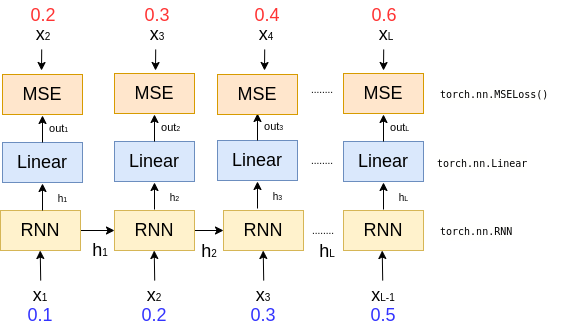

As you can see, the RNN scans all the time steps of the input sequence. At each step, the network predicts the next value. At time step $t$, the RNN is fed by the previous hidden state $h_{t-1}$ and by the previously predicted output ($out_t$). Actually, during training is it possible to feed the network with the previous actual value (label) rather than using the predicted one? This operation is called **teacher forcing**.

The term *autoregressive* derives from the previous output that is fed back into the system. The labels are simply derived from shifting the input sequence to the left.

You can use an autoregressive RNN for many applications (e.g., stock prediction. Here, for simplicity, we predict the next value of a sinusoidal signal. The sinusoids will have different frequencies and phases.

First of all, let's create a dataset for this problem.


### Exercise 4.1 &mdash; Dataset Creation
A sinusoid in the time domain can be written as:

$y(t) = A sin(2\pi ft + \phi)$, where:

- $A$ is the amplitude of the sinusoid.
- $f$ is the frequency of the sinusoid (in Hz).
- $t$ is the time expressed (in seconds).
- $\phi$ is the phase (shift) of the sinusoid (in radiants).

As shown in the figure below, we work with discrete sinusoids. We thus have to discretize the time axis by taking the value of the sinusoid at every $T_s$ second (sampling period).

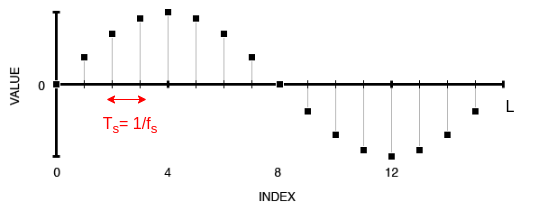

A discrete sinusoid can be written as:

$y[n] = A sin(2\pi f \frac{n}{f_s} + \phi)$, where:
*   $n$ is the index of the sequence element (e.g., $n=0$, $n=1$, $n=2$,.., $n=L-1$).
*   $f_s = \frac{1}{T_c}$ is the sampling rate (also called sampling frequency) expressed in Hz. In this exercise, we will use a fixed sample rate of 8000 Hz.

**Complete the code** to compute a sinusoid of length $L$ samples with a given $A$, $f$, $f_s$, and $\phi$:


In [78]:
def compute_sin(amp=1.0, freq=500, phi=0, sample_rate=8000, length=100):
    """Computes a sinusoid of length L samples given:
    - A (amplitude)
    - f (frequency in Hz)
    - phi (the phase shift in radiants)
    - sample_rate (sampling frequency in Hz)
    """
    n = torch.linspace(0, length - 1, length)
    sin = amp * torch.sin(2 * torch.pi * freq * n / sample_rate + phi)

    return sin

Now, you can plot some sinusoids generated with the code above.

**Write the code** to plot the sinusoid in the following three cases:
1. Plot the sinusoid with the default parameters.
2. Plot a sinusoid with frequency $f=100$ Hz.
3. Plot a sinusoid with frequency $f=1000$ Hz and $\phi=\pi/2$.


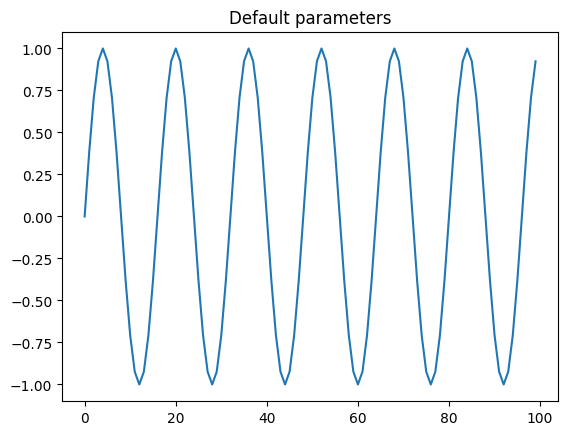

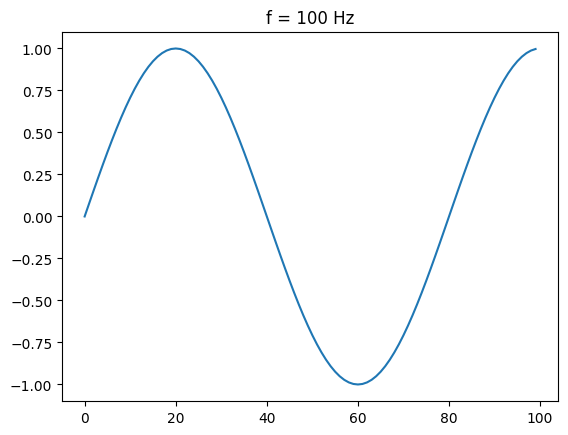

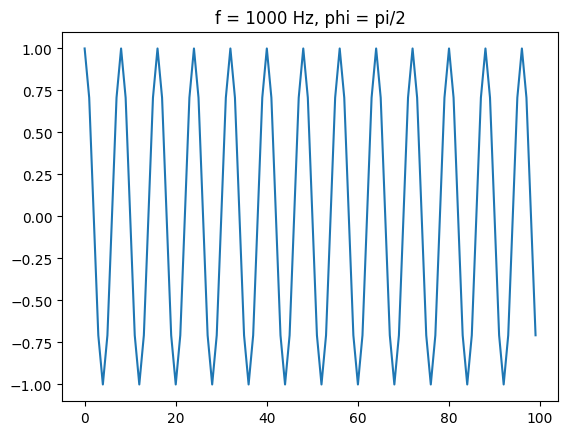

In [79]:
import matplotlib.pyplot as plt
import math

# 1. Plot the sinusoid with the default parameters
sin1 = compute_sin()
plt.figure(); plt.plot(sin1.numpy()); plt.title("Default parameters"); plt.show()

# 2. Plot a sinusoid with frequency f = 100 Hz
sin2 = compute_sin(freq=100)
plt.figure(); plt.plot(sin2.numpy()); plt.title("f = 100 Hz"); plt.show()

# 3. Plot a sinusoid with frequency f = 1000 Hz and phi = pi/2
sin3 = compute_sin(freq=1000, phi=math.pi/2)
plt.figure(); plt.plot(sin3.numpy()); plt.title("f = 1000 Hz, phi = pi/2"); plt.show()

You should see the following plots:

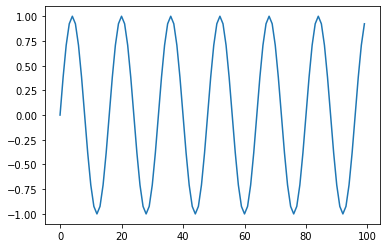


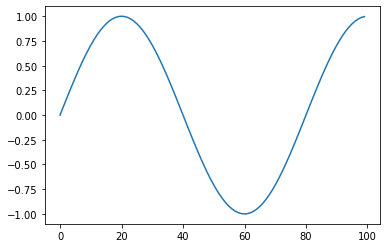


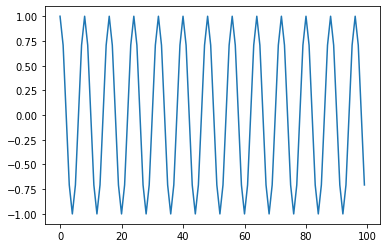

**Check your answer** by running the code cell below.

In [80]:
out = compute_sin()
assert out.dtype==torch.float32, "Expected out to be float 32"
assert out.shape[0]==100, "Unexpected shape"
assert out[0]==0.0, "t[0] must be zero (when phi is 0)"
out_90 = compute_sin(phi=0.5*math.pi)
assert torch.allclose((out**2 + out_90**2),torch.ones(100)), "Unexpected result when phi =pi/2"
out_180 = compute_sin(phi=math.pi)
assert (out_180+out).sum() < 1e-05, "Unexpected result when phi =pi/2"
out = compute_sin(amp=0)
assert out.sum()==0, "Something wrong with the amplitude A"
print("Correct!")

Correct!


Let's now create a dataset by drawing sinusoids with random frequency and phase. In particular, we would like to sample these two variables in the following way:

*  $f$ is sampled from a uniform distribution ranging from 100 ($fmin$) to 1000 Hz ($fmax$).
*  $\phi$ is sampled from a uniform distribution rangign from 0 ($phi\_min$) to $\pi$ ($phi\_max$).

For simplicity, we assume that the amplitude $A$ is one for the sinusoids.


**Complete the code** to draw N sinusoids of length L=100:


In [81]:
def generate_data(num_ex, length=100, amp=1.0, freq_min=100, freq_max=1000, phi_min=0, phi_max=math.pi):
    """Generates a dataset of sinusoids with different frequencies and phases.

    Arguments
    ---------
    num_ex: int
        Number of sinusoids to draw.
    length : int
        Length of the sinusoids.
    amp: float
        Amplitude of the sinusoids.
    freq_min: float
        Lower value of the frequency.
    freq_max: float
        Upper value of the frequency.
    phi_min: float
        Lower value of the phase.
    phi_max: float
        Upper value of the phase.

    Returns
    -------
    X: torch.Tensor
        Tensor of dimensionality (N,L,1) containing
        the generated sequences.
    """
    # Your code here. Aim for 9-10 lines.
    sequences = []
    for i in range(num_ex):
        freq = torch.empty(1).uniform_(freq_min, freq_max).item()
        phi = torch.empty(1).uniform_(phi_min, phi_max).item()
        sin = compute_sin(amp=amp, freq=freq, phi=phi, length=length)
        sequences.append(sin)

    X = torch.stack(sequences, dim=0)
    X = X.unsqueeze(2)  # (N, L, 1)

    return X

**Check your answer** by running the code cell below.

In [82]:
out = generate_data(15)
assert out.dtype==torch.float32, "Expected out to be float32"
assert out.shape==(15,100,1), "Unexpected shape"
out = generate_data(15, length=10)
assert out.shape==(15,10,1), "Unexpected shape"
out = generate_data(15, amp=0)
assert out.sum()==0, "Unexpected  output with amp=0"
out = generate_data(15, amp=1, length=100, freq_min=1000, freq_max=1000, phi_min=0, phi_max=0)
assert torch.allclose(out.min(),torch.Tensor([-1])), "Unexpected  output with amp=1"
assert torch.allclose(out.max(),torch.Tensor([1])), "Unexpected  output with amp=1"
out = generate_data(15, amp=1, freq_min=0, freq_max=0, phi_min=0, phi_max=0)
assert torch.allclose(out,torch.Tensor([0])), "Unexpected  output with f=0 and phi=0"
out = generate_data(15, amp=1, freq_min=0, freq_max=0, phi_min=math.pi/2, phi_max=math.pi/2)
assert torch.allclose(out,torch.Tensor([1])), "Unexpected  output with f=0 and phi=pi/2"
print("Correct!")

Correct!


Let's now generate the training and test data. We generate 2000 sequences for training and 200 for testing.


**Complete the code** to generate the training and test datasets. Also, plot one sinusoid from the training set and one from the test set.

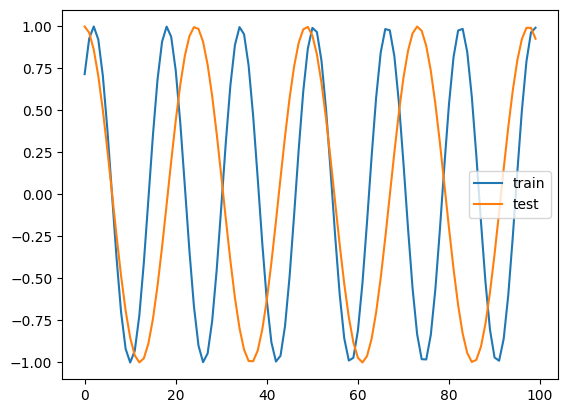

In [83]:
N_train = 2000
N_test = 200

# Data generation
tr_data = generate_data(2000)
te_data = generate_data(200)

# Plot (in the same figure) one sinusoid from training (tr_data[0])
# and one from test (te_data[0])
plt.figure()
plt.plot(tr_data[0, :, 0].numpy(), label='train')
plt.plot(te_data[0, :, 0].numpy(), label='test')
plt.legend()
plt.show()

You should plot something like this:

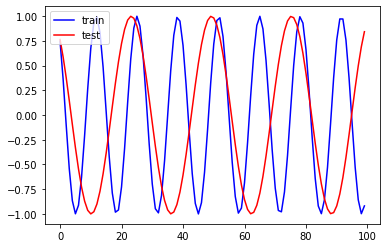

### Exercise 4.2 — Create the Model
We are now ready to implement the model described above.

In particular:

- The ` __init__`  has to initialize the RNN layer and the linear one with the expected dimensionalities. This time we employ a GRU (`torch.nn.GRU`) as an RNN. Use `batch_first=True` as done in previous exercises.

- The  forward  method has to first feed the inputs into the RNN. Then, a linear transformation is employed to convert each hidden state into a single real number.


**Complete the code** to implement the RNN:

In [84]:
class RNN(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=8, num_layers=1):
        super(RNN, self).__init__()
        self.rnn = torch.nn.GRU(input_size=1,
                                hidden_size=hidden_size,
                                num_layers=num_layers,
                                batch_first=True)
        self.linear = torch.nn.Linear(in_features=hidden_size,
                                      out_features=1)

    def forward(self, x):
        """This function processes with an RNN the input sequence x from the last
        element to the first one. On top of each hidden state, a linear transformation
        that returns a scalar prediction for each time step is applied.

        Arguments
        ---------
        x : torch.Tensor
            Tensor containing the sequences (N, L, 1).

        Returns
        -------
        out: torch.Tensor
            Tensor (N,L,1) containing the output prediction at each time step.
        """
        # Run the RNN + linear transformation
        H, _ = self.rnn(x)
        out = self.linear(H)

        return out

### Exercise 4.3 &mdash; Training Loop
Now, we can train the model. This is very similar to what was done in the previous exercises. The main differences are:
- this time we have to use the Mean Squared Error (MSE) as an objective (`torch.nn.MSELoss()`).
- you can derive the labels by shifting the input X to the left (one way is to use `torch.roll`). Note also that you have to remove the last time step to both
inputs and labels (due to the aforementioned shift).

**Complete the code** to implement the training loop:

In [85]:
# Hyperparameters
num_epoch = 100
batch_size = 128
lr = 0.01
hidden_size = 32
num_layers = 1

# Initialization
rnn = RNN(input_size=1, hidden_size=hidden_size, num_layers=num_layers)
loss = torch.nn.MSELoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=lr)

def training_loop(X, model, loss, optimizer, num_epoch=500, batch_size=100):

    # Derive labels by shifting X
    Y = torch.roll(X, -1, dims=1)

    # Remove the last time steps from X and Y
    X = X[:, 0:-1]
    Y = Y[:, 0:-1]

    N = X.shape[0]

    # Training Loop
    for epoch in range(num_epoch):
        for i in range(0, N, batch_size):

            # Minibatch selection (on X and y)
            Xi = X[i:i+batch_size]
            Yi = Y[i:i+batch_size]

            # Run the RNN
            predictions = model(Xi)

            # Compute the loss
            l = loss(predictions, Yi)

            # Update the parameters
            optimizer.zero_grad()
            l.backward()
            optimizer.step()

        # Print loss
        if (epoch + 1) % 10 == 0:
            print("Epoch %03d: Train_loss: %.4f " %(epoch+1, l.item()))

# Run the training loop
training_loop(tr_data, rnn, loss, optimizer, num_epoch, batch_size)

Epoch 010: Train_loss: 0.0027 
Epoch 020: Train_loss: 0.0017 
Epoch 030: Train_loss: 0.0014 
Epoch 040: Train_loss: 0.0013 
Epoch 050: Train_loss: 0.0013 
Epoch 060: Train_loss: 0.0013 
Epoch 070: Train_loss: 0.0013 
Epoch 080: Train_loss: 0.0013 
Epoch 090: Train_loss: 0.0013 
Epoch 100: Train_loss: 0.0013 


If everything is fine, you should obtain something like this:

```
Epoch 010: Train_loss: 0.0028
Epoch 020: Train_loss: 0.0016
Epoch 030: Train_loss: 0.0013
Epoch 040: Train_loss: 0.0013
Epoch 050: Train_loss: 0.0012
Epoch 060: Train_loss: 0.0012
Epoch 070: Train_loss: 0.0012
Epoch 080: Train_loss: 0.0011
Epoch 090: Train_loss: 0.0011
Epoch 100: Train_loss: 0.0011
```

As you can see, the loss is decreasing very fast in this case. Let's now compute the test loss:

**Complete the code** to implement the training loop:

In [86]:
# Setting the model in eval mode
rnn.eval()

# Get predictions on test data
predictions = rnn(te_data)

# Get labels by shifting the test data
Y_test = torch.roll(te_data, -1, dims=1)

# Remove the last time steps for both predictions and Y_test
predictions = predictions[:, 0:-1]
Y_test = Y_test[:, 0:-1]
loss_test = loss(predictions, Y_test)

# Print the test loss
print("Test_loss: %.4f " %(loss_test.item()))

Test_loss: 0.0013 


You should obtain a test loss very similar to the training loss:

`Test_loss: 0.0014 `

Now, we compare the target signal with the predicted one.

**Run the following code** to compare one target signal versus a predicted one.

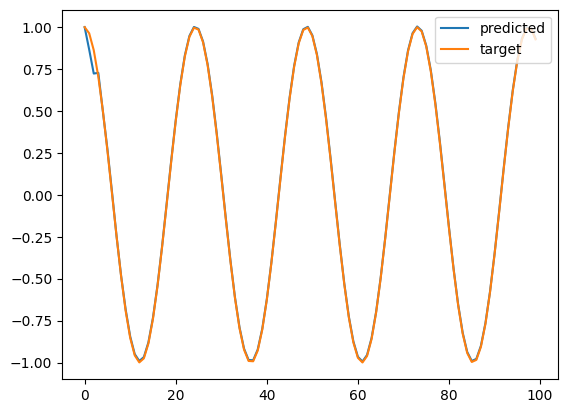

In [87]:
predicted_signal = torch.hstack([te_data[0,0,0], predictions[0,:,0]])
target_signal = te_data[0,:,0]
plt.plot(predicted_signal.detach(), label='predicted')
plt.plot(target_signal.detach(), label='target')
plt.legend(loc="upper right")
plt.show()

You should obtain an almost perfect matching between the targets and the predicted signals, as shown in the following figure:

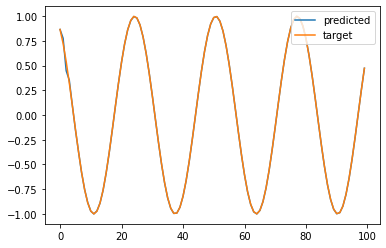

In this case, an RNN solves this simple task almost perfectly. It is indeed relatively easy for the network to observe all the past samples and figure out what could be the next one.

# 5. Language Models (Optional)
In this (optional) exercise, we ask you to generate a Shakespeare-like text. Don't worry, you don't have to write it by yourself. Instead, we will train a recurrent neural network to write it for you. To develop such a system, we will follow these steps:
1. We will train a character-based language model using text from Shakespeare's plays. The language model predicts the next character given the previous one (see figure below). This is very similar to what was done before. This time, we predict the next character rather than the next value of the sinusoid.
2. After training the RNN language model, we will generate new texts by properly "sampling" from it.


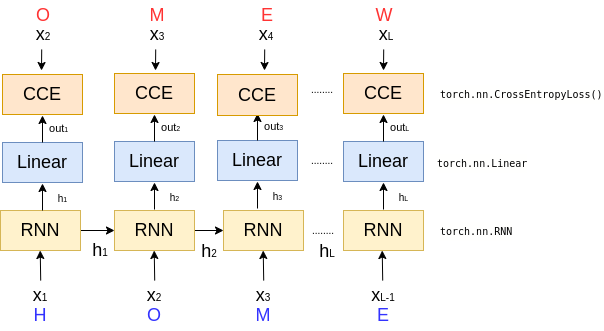

First of all, let's download the text data  from the web.

**Run the following code** to download the data.

In [88]:
# Download data from google drive repo:
!gdown --id 13WzBACCBG58H4xGzP_mGdpmmtvDUppZZ # Train data
!gdown --id 1G_VaOgs_eYs9vfkFVf0sJ1ELanq5zEuO  # Test data

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13WzBACCBG58H4xGzP_mGdpmmtvDUppZZ
To: /content/trainset.pkl
100% 689k/689k [00:00<00:00, 129MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1G_VaOgs_eYs9vfkFVf0sJ1ELanq5zEuO
To: /content/testset.pkl
100% 306k/306k [00:00<00:00, 117MB/s]


### Exercise 5.1 - Data Preparation
The training and test data are stored in two pickle files:
- trainset.pkl
- testset.pkl

**Write a code to read** the downloaded data. Training data must be stored in a variable called `train_data`, while test data must be stored in a variable called `test_data`.

In [89]:
import pickle

# Your code here. Aim for 4 lines
with open('trainset.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open('testset.pkl', 'rb') as f:
    test_data = pickle.load(f)

print(train_data[0])

 him? My cousin Juliet?

LUCIO:
Is she your cousin?

ISABELLA:
Adoptedly; as school-maids change the


As you can see, the data are saved in a list of strings where each element contains a string of 100 characters. For instance, if you print the first sentence of the training data (`print(train_data[0])`) you should see:


```
 him? My cousin Juliet?

LUCIO:
Is she your cousin?

ISABELLA:
Adoptedly; as school-maids change the
```

There are 6270 strings for training and 2790 for testing.

Before moving on, we have to write some support function that allows us to train our model. The first thing to do is to figure out which set of characters is used in the training set.


**Write a code** to define the set of characters. You have to join all the training data into a single big string. Then you have to use the function `set` followed by the `sorted` one to sort the set of characters. Finally, convert everything into a list.


In [90]:
# Write your code here (aim for 1-2 lines of code)
char_set = sorted(set(''.join(train_data)))
print(char_set)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


If you print `char_set` you have to see:

`['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F',..... ]`

The lenght of the output list must be 65.

We cannot feed characters into a neural network. We need to convert them into numbers. Now, you have to write a function that takes in input the dataset (either the list of strings in `train_data` or `test_data`) and converts all the characters into their corresponding index in the `char_set`.

For instance, the sequence of char "hello" must be converted into the following tensor of indexes: `tensor([[46, 43, 50, 50, 53]])`.

**Complete the code below** to convert the training and test dataset to their indexes. *Hint*: You can use the method `.index` in  `char_set` to find the index corresponding to a certain character.

In [91]:
def from_chars_to_indexes(data, char_set):
    """This function converts all the strings available in the data list into
    a tensor of indexes. The conversion between char and index is done based on
    the content of the char_set.

    Arguments
    ---------
    data : List
        A list containing strings to convert.

    char_set :    List
        A list containing the set of characters. The first element corresponds to
        index 0, the second to index 1, and so on.

    Returns
    -------
    data_index: torch.Tensor
        Tensor (N,L) containing the indexes corresponding to the input chars. N is
        the number of text chunks and L is the number of char in each chunk.
    """
    # Your code here. Aim for 8-10 lines
    sequences = []
    for string in data:
        indices = []
        for char in string:
            indices.append(char_set.index(char))
        sequences.append(indices)

    data_index = torch.tensor(sequences, dtype=torch.int64)

    return data_index

# Convert the train and test data
train_data = from_chars_to_indexes(train_data, char_set)
test_data = from_chars_to_indexes(test_data, char_set)

**Check your answer** by running the code below:

In [92]:
print(from_chars_to_indexes(['hello'], char_set))
assert train_data.dtype==torch.int64, "Expected out to be int64"
assert train_data.shape==(6270,100), "Unexpected shape"
assert test_data.dtype==torch.int64, "Expected out to be int64"
assert test_data.shape==(2790,100), "Unexpected shape"
assert test_data.min()==0, "Unexpected min index"
assert test_data.max()==64, "Unexpected max index"
ind =  from_chars_to_indexes(['hello'], char_set)
ind_expected = torch.Tensor([[46, 43, 50, 50, 53]])
assert torch.equal(ind.float(),ind_expected), "Unexpeced index conversion"
print("Correct!")

tensor([[46, 43, 50, 50, 53]])
Correct!


For this exercise, we convert our datasets into PyTorch data loader objects. This operation is generally convenient because the data loader object implements useful functionalities. For instance, it creates batches for us, shuffles data, etc.

For more information see [this tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).

**Run the code below** to create the data loader for the training data.

In [93]:
batch_size = 128
# First, we have to convert our list into a dataset object
tr_dataset = torch.utils.data.TensorDataset(train_data)

# Finally, we can create the Dataloader object
tr_loader = torch.utils.data.DataLoader(tr_dataset, batch_size=batch_size, shuffle=True)

### Exercise 5.2 — Create the Model
We are now ready to implement the model described above. The model is essentially the same as the one implemented in the previous exercise.

The main differences are the following:
- This time, we use an LSTM (`torch.nn.LSTM`). See the documentation [here](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html).

- We use dropout as well within the LSTM. Just pass the dropout variable (set by default to 0.1) when you initialize the LSTM.

- Before feeding the char indexes into the network, we have to convert the indexes into embedding vectors. This can be done with `torch.nn.Embedding` (see the documentation [here](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)). We can choose an embedding dimension of 75.

- Since we use the categorical cross-entropy loss, we do not have to convert the linear transformation into a set of probabilities using the softmax (at training/test time). This step is already included in `torch.nn.CrossEntropyLoss` (see the documentation [here](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)).

- This time, we will feed the initial hidden state h_0 into the RNN (by default it is set to None). Moreover, we return the last hidden state of the RNNs as well (see `torch.nn.LSTM` documentation). This will be useful later when we will use the model to generate text.


**Complete the code below** to create the RNN for language modeling.

In [94]:
class charRNN(torch.nn.Module):
    def __init__(self, char_set_size=10, embedding_dim=75, hidden_size=8, num_layers=1, dropout=0.1):
        super(charRNN, self).__init__()
        self.embedder = torch.nn.Embedding(char_set_size, embedding_dim)
        self.rnn = torch.nn.LSTM(input_size=embedding_dim,
                                 hidden_size=hidden_size,
                                 num_layers=num_layers,
                                 batch_first=True,
                                 dropout=dropout)
        self.linear = torch.nn.Linear(in_features=hidden_size,
                                      out_features=char_set_size)

    def forward(self, X, h_0=None):
        """This function processes the input sequence X from the last
        element to the first one using an RNN.
        On top of each hidden state, a linear transformation
        that returns a scalar prediction for each time step is applied.

        Arguments
        ---------
        X : torch.Tensor
            Tensor containing the sequence of char (N, L).
        h_0 : torch.Tensor
            Initial hidden state. By default is None. This means that it will be
            internally initialized to zero when instantiating the torch.nn.LSTM object.

        Returns
        -------
        out: torch.Tensor
            Tensor (N,L,char_set_size) containing the output at each time step.
        h_n: torch.Tensor
            Last hidden state.
        """
        # Run the RNN encoder
        # Your code here. Aim for 3 lines
        embeddings = self.embedder(X)
        H, h_n = self.rnn(embeddings, h_0)
        out = self.linear(H)

        return out, h_n

### Exercise 5.3 &mdash; Training Loop
Now, we can train the model. This step is very similar to what was done in the previous exercise. We have to use the Categorical Cross-Entropy as an objective function. This requires properly transposing the tensor to match the dimensionality expected by this loss function.
As in the previous exercise, you can derive the labels $y$ by shifting the input X to the left (one way is to use `torch.roll`). Remember to remove the last time step to both inputs and labels (due to the aforementioned shift).

**Note**: training this model takes long some time on the CPU. It only takes 7-8 minutes using the GPU. To use the GPU, go to `Runtime`=>`Change runtime type` and choose `GPU` as hardware accelerator". Note that this will **change the computing node** (and it will cancel all the previous output). If that happens, you just have to run the previous steps (the code won't be deleted of course).

**Complete the code** to implement the training loop:

In [96]:
# Hyperparameters
num_epoch = 100
lr = 0.001
hidden_size = 256
num_layers = 2
embedding_dim = 75
dropout = 0.5
batch_size = 64
device = 'cuda:0'

# Initialization
rnn = charRNN(char_set_size=len(char_set),
              embedding_dim=embedding_dim,
              hidden_size=hidden_size,
              num_layers=num_layers,
              dropout=dropout)
rnn.to(device)
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=lr)

tr_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_data),
    batch_size=batch_size, shuffle=True)

def training_loop(X, model, loss, optimizer, num_epoch=500, batch_size=100, device='cpu'):

    # Training Loop
    for epoch in range(num_epoch):

        for i, X in enumerate(tr_loader):

            # Input/Labels Manipulation
            X = X[0]
            y = torch.roll(X, -1, dims=1)
            X = X[:, :-1]
            y = y[:, :-1]
            X = X.to(device)
            y = y.to(device)

            # Run the RNN
            out, hn = model(X)

            # Compute the loss
            l = loss(out.transpose(1, 2), y)

            # Update the parameters
            optimizer.zero_grad()
            l.backward()
            optimizer.step()

        # Print loss
        if (epoch + 1) % 10 == 0:
            print("Epoch %03d: Train_loss: %.4f " %(epoch+1, l.item()))

# Run the training loop
training_loop(train_data, rnn, loss, optimizer, num_epoch, batch_size, device)

Epoch 010: Train_loss: 1.5894 
Epoch 020: Train_loss: 1.4596 
Epoch 030: Train_loss: 1.3971 
Epoch 040: Train_loss: 1.3238 
Epoch 050: Train_loss: 1.3072 
Epoch 060: Train_loss: 1.2501 
Epoch 070: Train_loss: 1.2288 
Epoch 080: Train_loss: 1.2143 
Epoch 090: Train_loss: 1.1909 
Epoch 100: Train_loss: 1.1576 


Over the 100 epochs, you should obtain the following training losses:


```
Epoch 010: Train_loss: 1.7946
Epoch 020: Train_loss: 1.5637
Epoch 030: Train_loss: 1.4523
Epoch 040: Train_loss: 1.4279
Epoch 050: Train_loss: 1.3672
Epoch 060: Train_loss: 1.3551
Epoch 070: Train_loss: 1.3228
Epoch 080: Train_loss: 1.2903
Epoch 090: Train_loss: 1.2544
Epoch 100: Train_loss: 1.2200
```



Now, let's take a look at the performance on the test set.

**Complete the code below** to compute the loss on the test data.

In [97]:
# Switch RNN to eval modality
rnn.eval()

# Put test data on the right device
test_data = test_data.to(device)

# Running the charRNN on test data
out, _ = rnn(test_data[:, :-1])

# Derive test labels (left shift)
y_test = torch.roll(test_data, -1, dims=1)

# Remove last time step
out = out
y_test = y_test[:, :-1]

# Compute the loss
loss_test = loss(out.transpose(1, 2), y_test)

# Print the test loss
print("Test_loss: %.4f " %(loss_test.item()))

Test_loss: 1.4624 


You should obtain a test loss very similar to the training loss:

`Test_loss: 1.4350`

The network is trained on a small text corpus. It tends to slightly overfit despite using dropout as a regularization technique. However, this is not a big issue as the overfitting is minimal.


### Exercise 5.5 &mdash; Text Generation
Do you think it makes sense to use a bidirectional RNN in this case? Write Yes/No and explain clearly your answer.

No, The usage of a bidirectional RNN for text generation is not logical. Given only the preceding characters, the autoregressive model in this challenge predicts the subsequent character. One character at a time, we generate text at generation time, returning each predicted character as input. Future characters (the backward pass), which are unavailable during creation, would be necessary for a bidirectional RNN. A bidirectional RNN would be incompatible with the autoregressive generation process since it would require information that isn't available at inference time.

### Exercise 5.6 &mdash; Text Generation
We are now ready to generate text from our pre-trained RNN. *How can we do that?*

One possible approach is the following:
1. We select a random initial input character.
2. We compute the output probability. We have here to apply the softmax on the output provided by the CharRNN.
3. We select an output character by sampling from the output probability. The sampling can be done using `torch.multinomial` (see documentation [here](https://pytorch.org/docs/stable/generated/torch.multinomial.html)).
4. Repeat steps 2 and 3 until L characters are generated.

Essentially, we generate all the characters one by one within a for loop (this is why we designed the RNN such that it takes in input and hidden state and gives in output another hidden state).


**Complete the following code** to generate text.

In [98]:
def generate(rnn, L=100):
    """This function generates text of length L characters using the RNN model
    in input

    Arguments
    ---------
    rnn : charRNN object
        Pretrained RNN model used to generate text.
    L : int
        Length of the text to generate.

    Returns
    ---------
    output_text: string
        String containing the generated text.
    """

    # Random sample an input char index (use torch.randint)
    current_input = torch.randint(len(char_set), (1,1), device=device)

    # Initialize the output text
    output_text = ''

    # Loop over all the time steps
    for i in range(L):

        if i==0:
            # Manage the first step
            # Feed the RNN with the current input without giving the hidden state.
            out, h = rnn(current_input)
        else:
            # Feed the RNN with the current input giving the hidden state in input as well
            out, h = rnn(current_input, h_in)

        # Compute probabilities from the output (use torch.nn.functional.softmax)
        probs = torch.nn.functional.softmax(out[0, -1], dim=0)

        # Sample the current output from the probabilities (use torch.multinomial)
        current_output = torch.multinomial(probs, 1).unsqueeze(0)

        # Add current output to output text
        output_text = output_text + char_set[current_input]

        # Update hidden state (for next h_in)
        h_in = h

        # Update input (for next current input)
        current_input = current_output

    return output_text

rnn.eval()
text = generate(rnn, L=600)
print(text)

uar shall be eat! in God's head,
To happing in menness for my hours.

KING RICHARD III:
Believe not to him to the Copbill!

KING HENRY VI:
Be apacle, very grace were statedly,
Sometime by the ill-even of thee: with with worlds
Of some ible to the anchs of her fault,
And bleading my dear living down to-morrow;
One blood thou dost beseech the mam's which way
And give to me: I fry was unsellest death,
Lest from Lumentage in Say dit in meant,
See he advanced by the infilted.
There is thy soldier to the elder beast!
For you are delispaiting him and by the Wanton
Had swounds attend like an younger c


If the generation step is implemented correctly, you should obtain text like this (every time you run it you sample something different):


```
;
And I not like my man, you weep as his will be my love.
The watch in the Pawak of their greats. But if
it is the Cousiny.

PROSPERO:
O Lord Edward, we have barner'd you.

STANLEY:
My lord
Shall be he very deed by your precains out
That much not want: your heeds, would not hear you.
Farewell, faith, and let thee to be that flow.
But their crowment hand with a-standing friends?

KING RICHARD III:
We are this mad: we'll cried my true stain,
Sen thee you from the lives there.

OXFORD:
Then, for thy sheel-stable--

First Lord:
Not sir, for I did continue this curbers:
O that make him speak, or I
```

You should see that most of the time, the RNN produces valid words. We can see that the network has learned to separate the parts assigned to different actors. The sequence of generated words might make some sense locally, but not globally. For better results, larger models on larger datasets must be used (which is out of the scope of this assignment).

**That's all!**



